In [43]:
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split 
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import cross_val_score 
from xgboost import XGBClassifier
from sklearn.metrics import classification_report , ConfusionMatrixDisplay
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

In [10]:
#data

import kagglehub
from kagglehub import KaggleDatasetAdapter
file_path = "spam_ham_dataset.csv"


df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "venky73/spam-mails-dataset",
  file_path,
)


/home/ateeksh/Spam_classifier_Project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_174838/518707742.py:8: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


In [11]:
df.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [12]:
target = np.array(df["label_num"])

In [13]:
data = np.array(df["text"])

In [14]:
x_train_full , x_test , y_train_full , y_test = train_test_split(data , target , test_size=0.15 ,
                                                                 random_state=42)

x_train , x_valid , y_train , y_valid = train_test_split(x_train_full , y_train_full , test_size=0.15,
                                                         random_state=42)

In [25]:
log_reg = make_pipeline(TfidfVectorizer() , 
                        LogisticRegression(max_iter=1000 ,random_state= 42 ))



In [26]:
navie_bayes = make_pipeline(TfidfVectorizer() , 
                        MultinomialNB())



In [27]:
svc = make_pipeline(TfidfVectorizer() ,
                    LinearSVC())

In [28]:
def cross_val(pipeline , x_train , y_train):
    scores_parameters_list = ["precision" , "recall" , "f1"]
    
    for scoring_parameter in scores_parameters_list:
        score = cross_val_score(pipeline , x_train , y_train , cv=3 , scoring=scoring_parameter)  
        print(f"{scoring_parameter} : {score.mean()}")
        


In [29]:
cross_val(log_reg , x_train , y_train)

precision : 0.9567849428168808
recall : 0.972502245229518
f1 : 0.9645573335224249


In [30]:
cross_val(navie_bayes , x_train , y_train)

precision : 1.0
recall : 0.45188145188145185
f1 : 0.621917191584564


In [31]:
cross_val(svc , x_train , y_train)

precision : 0.9591920494113525
recall : 0.9880876699058517
f1 : 0.9733829225940025


In [32]:
svc.fit(x_train , y_train )

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidfvectorizer', ...), ('linearsvc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [35]:
y_pred = svc.predict(x_test)
classification_report(y_test , y_pred , target_names=["spam" , "ham"])

'              precision    recall  f1-score   support\n\n        spam       0.99      0.99      0.99       553\n         ham       0.97      0.99      0.98       223\n\n    accuracy                           0.99       776\n   macro avg       0.98      0.99      0.99       776\nweighted avg       0.99      0.99      0.99       776\n'

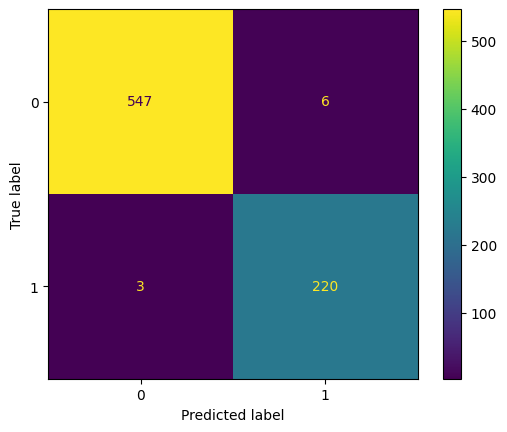

In [42]:
plt.rc('font' , size=10)
ConfusionMatrixDisplay.from_predictions(y_test , y_pred)

plt.show()

In [46]:
joblib.dump(svc , "../models/spam_classifier_pipeline.pkl")

['../models/spam_classifier_pipeline.pkl']